# LAB 08: NHẬN DIỆN ĐỐI TƯỢNG TRONG VIDEO (VIDEO DETECTION)

## Bước 1: Cài đặt thư viện

In [1]:
# Cài đặt ImageAI và các thư viện phụ thuộc
!pip install imageai --upgrade
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install opencv-python matplotlib

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (

## Bước 2: Tải model weights

Tải file `retinanet_resnet50_fpn_coco-eeacb38b.pth` từ link:
https://github.com/OlafenwaMoses/ImageAI/releases/download/3.0.0-pretrained/retinanet_resnet50_fpn_coco-eeacb38b.pth

In [5]:
import os
import urllib.request

model_filename = 'retinanet_resnet50_fpn_coco-eeacb38b.pth'
model_url = 'https://github.com/OlafenwaMoses/ImageAI/releases/download/3.0.0-pretrained/' + model_filename

if not os.path.exists(model_filename):
    print('Đang tải model weights (~130MB), vui lòng chờ...')
    
    def show_progress(block_num, block_size, total_size):
        downloaded = block_num * block_size
        percent = min(downloaded / total_size * 100, 100)
        print(f'\r  {percent:.1f}% ({downloaded//1024//1024}MB / {total_size//1024//1024}MB)', end='')
    
    urllib.request.urlretrieve(model_url, model_filename, reporthook=show_progress)
    print('\nTải xong!')
else:
    print(f'Model đã tồn tại: {os.path.abspath(model_filename)}')

Đang tải model weights (~130MB), vui lòng chờ...
  100.0% (130MB / 130MB)
Tải xong!


## Bước 4: Kiểm tra video trước khi detect

Thông tin video: video_predetect.mp4
  - Kích thước: 768 x 432 pixels
  - FPS: 25.0
  - Số frames: 436
  - Thời lượng: 17.4 giây


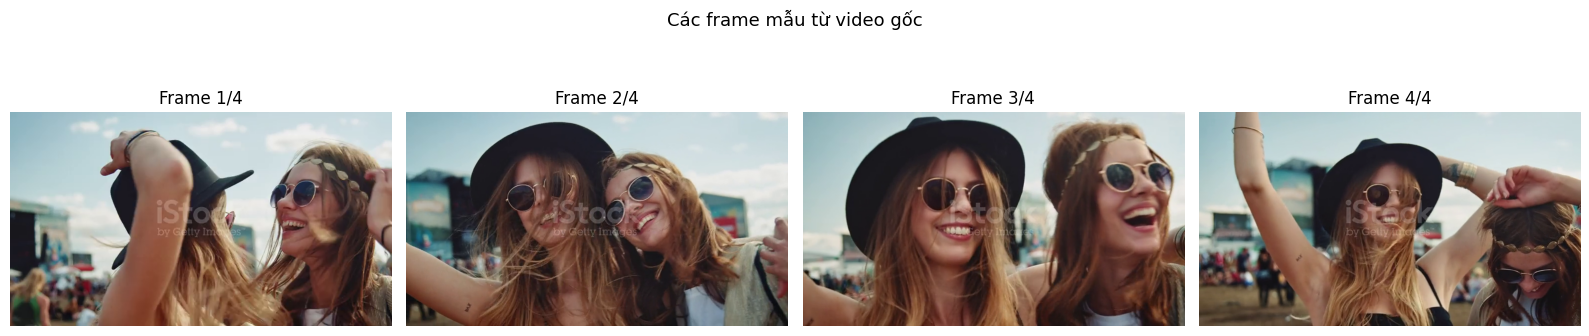

In [6]:
import cv2
import matplotlib.pyplot as plt
import os

video_input = 'video_predetect.mp4'

if not os.path.exists(video_input):
    print(f'CẢNH BÁO: Không tìm thấy file {video_input}')
    print('Vui lòng upload file video trước khi tiếp tục.')
else:
    cap = cv2.VideoCapture(video_input)
    fps     = cap.get(cv2.CAP_PROP_FPS)
    width   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = n_frames / fps if fps > 0 else 0

    print(f'Thông tin video: {video_input}')
    print(f'  - Kích thước: {width} x {height} pixels')
    print(f'  - FPS: {fps:.1f}')
    print(f'  - Số frames: {n_frames}')
    print(f'  - Thời lượng: {duration:.1f} giây')

    # Hiển thị một số frame mẫu
    sample_frames = []
    for i in range(min(4, n_frames)):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i * n_frames / 4))
        ret, frame = cap.read()
        if ret:
            sample_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    if sample_frames:
        fig, axes = plt.subplots(1, len(sample_frames), figsize=(16, 4))
        if len(sample_frames) == 1:
            axes = [axes]
        for idx, (ax, frm) in enumerate(zip(axes, sample_frames)):
            ax.imshow(frm)
            ax.set_title(f'Frame {idx+1}/{len(sample_frames)}')
            ax.axis('off')
        plt.suptitle('Các frame mẫu từ video gốc', fontsize=13)
        plt.tight_layout()
        plt.show()

## Bước 5: Nhận diện đối tượng trong video bằng ImageAI

In [7]:
# NHẬN DIỆN ĐỐI TƯỢNG TRONG VIDEO 
from imageai.Detection import VideoObjectDetection
import os

execution_path = os.getcwd()

detector = VideoObjectDetection()
detector.setModelTypeAsRetinaNet()
detector.setModelPath(os.path.join(execution_path, 'retinanet_resnet50_fpn_coco-eeacb38b.pth'))
detector.loadModel()

print('Model đã được load thành công!')
print('Bắt đầu nhận diện đối tượng trong video...')

video_path = detector.detectObjectsFromVideo(
    input_file_path=os.path.join(execution_path, 'video_predetect.mp4'),
    output_file_path=os.path.join(execution_path, 'video_detected'),
    frames_per_second=5,
    log_progress=True
)

print(f'\nHoàn thành Video kết quả được lưu tại: {video_path}')

c:\Users\Dung\anaconda3\envs\torch_cpu\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Dung\anaconda3\envs\torch_cpu\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
c:\Users\Dung\anaconda3\envs\torch_cpu\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
  warnings.warn(
c:\Users\Dung\anaconda3\envs\torch_cpu\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights_backbone' are deprecated since 0.13 and 

Model đã được load thành công!
Bắt đầu nhận diện đối tượng trong video...
Processing Frame :  1
Processing Frame :  2
Processing Frame :  3
Processing Frame :  4
Processing Frame :  5
Processing Frame :  6
Processing Frame :  7
Processing Frame :  8
Processing Frame :  9
Processing Frame :  10
Processing Frame :  11
Processing Frame :  12
Processing Frame :  13
Processing Frame :  14
Processing Frame :  15
Processing Frame :  16
Processing Frame :  17
Processing Frame :  18
Processing Frame :  19
Processing Frame :  20
Processing Frame :  21
Processing Frame :  22
Processing Frame :  23
Processing Frame :  24
Processing Frame :  25
Processing Frame :  26
Processing Frame :  27
Processing Frame :  28
Processing Frame :  29
Processing Frame :  30
Processing Frame :  31
Processing Frame :  32
Processing Frame :  33
Processing Frame :  34
Processing Frame :  35
Processing Frame :  36
Processing Frame :  37
Processing Frame :  38
Processing Frame :  39
Processing Frame :  40
Processing Fram

## Bước 6: Xem frame mẫu sau khi detect

Video kết quả: video_detected.mp4 (436 frames)


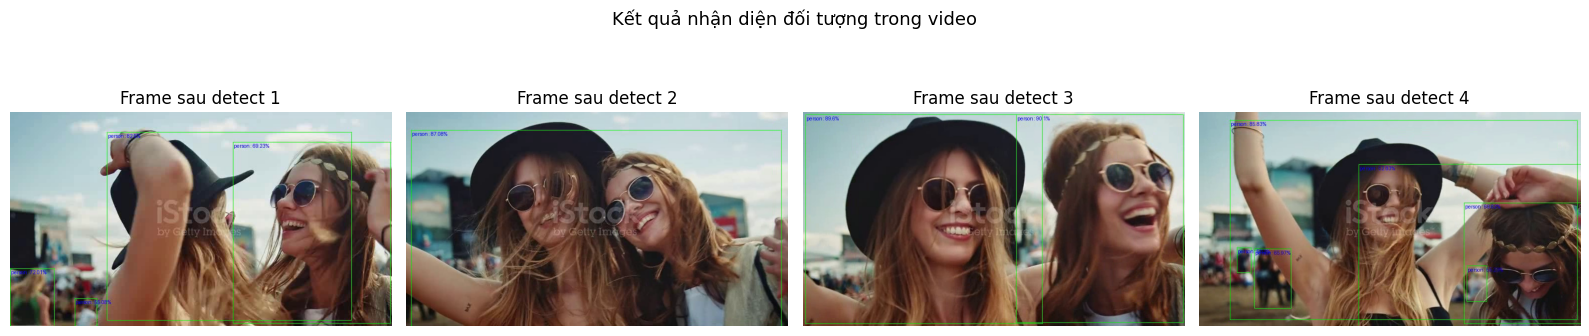

In [1]:
import cv2
import matplotlib.pyplot as plt
import os

# File output thường được thêm đuôi .avi hoặc .mp4 tự động bởi ImageAI
output_candidates = [
    'video_detected.mp4',
    'video_detected.avi',
]

output_video = None
for f in output_candidates:
    if os.path.exists(f):
        output_video = f
        break

if output_video is None:
    print('Chưa tìm thấy video kết quả. Hãy chạy bước 5 trước.')
else:
    cap = cv2.VideoCapture(output_video)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'Video kết quả: {output_video} ({n_frames} frames)')

    # Hiển thị 4 frame mẫu
    sample_frames = []
    for i in range(min(4, n_frames)):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i * n_frames / 4))
        ret, frame = cap.read()
        if ret:
            sample_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    if sample_frames:
        fig, axes = plt.subplots(1, len(sample_frames), figsize=(16, 4))
        if len(sample_frames) == 1:
            axes = [axes]
        for idx, (ax, frm) in enumerate(zip(axes, sample_frames)):
            ax.imshow(frm)
            ax.set_title(f'Frame sau detect {idx+1}')
            ax.axis('off')
        plt.suptitle('Kết quả nhận diện đối tượng trong video', fontsize=13)
        plt.tight_layout()
        plt.show()

## Bước 7: Tải video kết quả về máy

In [2]:
# Download video kết quả về máy tính (chỉ dùng trên Google Colab)
import os

output_candidates = ['video_detected.mp4', 'video_detected.avi']
output_video = next((f for f in output_candidates if os.path.exists(f)), None)

if output_video:
    try:
        from google.colab import files
        print(f'Đang tải xuống: {output_video}')
        files.download(output_video)
        print('Hoàn thành! Đổi tên file thành: 2374802010492_HuynhNgocAnhThu_252_71ITAI40603_0101_Lab08.mp4')
    except ImportError:
        print(f'File kết quả: {output_video}')
        print('Hãy copy file này và đổi tên thành: 2374802010492_HuynhNgocAnhThu_252_71ITAI40603_0101_Lab08.mp4')
else:
    print('Chưa tìm thấy video kết quả. Hãy chạy bước 5 trước.')

File kết quả: video_detected.mp4
Hãy copy file này và đổi tên thành: 2374802010492_HuynhNgocAnhThu_252_71ITAI40603_0101_Lab08.mp4
